In [1]:
import xarray as xr
import pandas as pd
import torch
import numpy as np
import torch.nn as nn
from torch.autograd import grad
import wandb

wandb.login()
wandb.init(project='twsa-PINNs')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: ravindrakapse308 (ravindrakapse308-indian-institute-of-science). Use `wandb login --relogin` to force relogin


In [2]:
import xarray as xr
import pandas as pd
import torch
import numpy as np
import torch.nn as nn
from torch.autograd import grad
file_path_grace = '../amazone_grace_interpolated_2003_1_2022_12.nc'
file_path_era5 = '../combined_2003_2022.nc'
ds_e = xr.open_dataset(file_path_era5)
ds_g = xr.open_dataset(file_path_grace)
ds_g

<xarray.Dataset>
Dimensions:        (index: 240)
Coordinates:
  * index          (index) int64 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
Data variables:
    time           (index) datetime64[ns] ...
    lwe_thickness  (index) float32 ...

In [27]:
ds_e

<xarray.Dataset>
Dimensions:      (valid_time: 7305, variable: 3)
Coordinates:
    number       int64 ...
  * valid_time   (valid_time) datetime64[ns] 2003-01-01 ... 2022-12-31
    spatial_ref  int64 ...
  * variable     (variable) object 'tp' 'ro' 'e'
Data variables:
    tp           (variable, valid_time) float32 ...

In [3]:
ds_g['time'].values

array(['2003-01-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2003-03-01T00:00:00.000000000', '2003-04-01T00:00:00.000000000',
       '2003-05-01T00:00:00.000000000', '2003-06-01T00:00:00.000000000',
       '2003-07-01T00:00:00.000000000', '2003-08-01T00:00:00.000000000',
       '2003-09-01T00:00:00.000000000', '2003-10-01T00:00:00.000000000',
       '2003-11-01T00:00:00.000000000', '2003-12-01T00:00:00.000000000',
       '2004-01-01T00:00:00.000000000', '2004-02-01T00:00:00.000000000',
       '2004-03-01T00:00:00.000000000', '2004-04-01T00:00:00.000000000',
       '2004-05-01T00:00:00.000000000', '2004-06-01T00:00:00.000000000',
       '2004-07-01T00:00:00.000000000', '2004-08-01T00:00:00.000000000',
       '2004-09-01T00:00:00.000000000', '2004-10-01T00:00:00.000000000',
       '2004-11-01T00:00:00.000000000', '2004-12-01T00:00:00.000000000',
       '2005-01-01T00:00:00.000000000', '2005-02-01T00:00:00.000000000',
       '2005-03-01T00:00:00.000000000', '2005-04-01

In [4]:
ds_g['lwe_thickness'].values

array([-6.13635331e-02,  1.05102472e-02,  7.04180598e-02,  1.32465079e-01,
        1.40444115e-01,  8.56688395e-02,  3.81277464e-02, -1.00427955e-01,
       -1.60072550e-01, -1.87212005e-01, -1.64097056e-01, -1.23037703e-01,
       -6.79591149e-02,  7.93870259e-03,  7.91765526e-02,  1.32335976e-01,
        1.37771398e-01,  8.33026990e-02,  2.00696979e-02, -8.07848871e-02,
       -1.64009199e-01, -1.70849115e-01, -1.70062974e-01, -1.17105357e-01,
       -6.70571178e-02,  1.12865437e-02,  1.08673111e-01,  1.55446887e-01,
        1.44170538e-01,  6.25386983e-02, -3.91031913e-02, -1.54345036e-01,
       -2.27941141e-01, -2.43897900e-01, -2.22360864e-01, -1.23216316e-01,
        6.23145700e-03,  9.82913598e-02,  1.53712794e-01,  2.14395314e-01,
        1.97350606e-01,  1.28455326e-01, -1.09694228e-02, -8.07595104e-02,
       -2.03922391e-01, -2.00555503e-01, -1.98243156e-01, -8.41458961e-02,
       -4.25227359e-03,  3.40014175e-02,  8.68193060e-02,  1.54400349e-01,
        1.69082657e-01,  

# Preprocessing

In [61]:
import xarray as xr
import numpy as np
import torch
import pandas as pd

# Load ERA5 and GRACE data
file_path_grace = '../amazone_grace_interpolated_2003_1_2022_12.nc'
file_path_era5 = '../combined_2003_2022.nc'

ds_era5 = xr.open_dataset(file_path_era5)
ds_grace = xr.open_dataset(file_path_grace)

# Extract data variables
precip = ds_era5['tp'][0].values  # precipitation
evap = ds_era5['tp'][2].values  # evapotranspiration
runoff = ds_era5['tp'][1].values  # runoff
grace_tws = ds_grace['lwe_thickness'].values  # lwe_thickness from GRACE

time = ds_era5['valid_time'].values  
grace_time = ds_g['time'].values

In [62]:

def normalize(data):
    return (data - np.mean(data)) / np.std(data)

# Normalize the data
precip = normalize(precip)
evap = normalize(evap)
runoff = normalize(runoff)
grace_tws = normalize(grace_tws)

# Cyclic encoding of time
day_of_year = pd.to_datetime(time).dayofyear
day_sin = np.sin(2 * np.pi * day_of_year / 365.25)
day_cos = np.cos(2 * np.pi * day_of_year / 365.25)

# Create a sequential time index
time_index = np.arange(len(time))

# Convert everything to PyTorch tensors
time_day_sin = torch.tensor(day_sin, dtype=torch.float32, requires_grad=True)
time_day_cos = torch.tensor(day_cos, dtype=torch.float32, requires_grad=True)
time_tensor = torch.tensor(time_index, dtype=torch.float32, requires_grad=True)
precip_tensor = torch.tensor(precip, dtype=torch.float32, requires_grad=True)
evap_tensor = torch.tensor(evap, dtype=torch.float32, requires_grad=True)
runoff_tensor = torch.tensor(runoff, dtype=torch.float32, requires_grad=True)
grace_tensor = torch.tensor(grace_tws, dtype=torch.float32, requires_grad=True)


# NN Model

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a custom sinusoidal activation function
class SinusoidalActivation(nn.Module):
    def __init__(self):
        super(SinusoidalActivation, self).__init__()

    def forward(self, x):
        return torch.sin(x)

class ComplexPINN(nn.Module):
    def __init__(self):
        super(ComplexPINN, self).__init__()
        
        # Update the count of input features: sin_time, cos_time, time_index, precipitation, evaporation, runoff
        input_features = 6
        
        # Neural network layers
        self.fc1 = nn.Linear(input_features, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 128)
        self.fc5 = nn.Linear(128, 64)
        self.fc6 = nn.Linear(64, 32)
        self.fc7 = nn.Linear(32, 1)
        
        # Regularization and normalization
        self.dropout = nn.Dropout(p=0.2)
        self.layer_norm1 = nn.LayerNorm(128)
        self.layer_norm2 = nn.LayerNorm(64)

        # Activation function
        self.sin_activation = SinusoidalActivation()

    def forward(self, sin_time, cos_time, time_index, precip, evap, runoff):
        # Stack all input features into a single input tensor
        x = torch.stack([sin_time, cos_time, time_index, precip, evap, runoff], dim=1)
        
        # Pass the input through the neural network
        x = self.sin_activation(self.fc1(x))
        x = self.sin_activation(self.layer_norm1(self.fc2(x)))
        x = self.sin_activation(self.fc3(x))
        x = self.sin_activation(self.dropout(self.fc4(x)))  # Apply dropout
        x = self.sin_activation(self.layer_norm2(self.fc5(x)))
        x = self.sin_activation(self.fc6(x))
        
        # Final output layer
        return self.fc7(x)

# Initialize the model
model = ComplexPINN()


In [65]:
import torch
import torch.nn as nn
import torch.autograd as autograd
import numpy as np

# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Physics-Informed Loss: Time derivative of TWSA
def physics_loss(time_index, model_output):
    # Compute dTWSA/dt using autograd
    dTWSA_dt = autograd.grad(outputs=model_output, inputs=time_index, grad_outputs=torch.ones_like(model_output), create_graph=True)[0]

    # Physics loss: dTWSA/dt = P - E - RO
    balance = dTWSA_dt - (precip_tensor + evap_tensor - runoff_tensor)
    return torch.mean(balance**2)

# Training loop
n_epochs = 10000
for epoch in range(n_epochs):
    model.train()
    
    # Predict TWSA
    predicted_tws = model(time_day_sin, time_day_cos, time_tensor, precip_tensor, evap_tensor, runoff_tensor)
    
    # Compute physics loss
    phys_loss = physics_loss(time_tensor, predicted_tws)
    
    # Aggregate daily TWSA to monthly
    monthly_tws = []
    start_idx = 0
    
    for year in range(2003, 2023):
        # Determine if it's a leap year
        if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0):
            days_in_month = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
        else:
            days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

        for days in days_in_month:
            month_tws = predicted_tws[start_idx:start_idx + days].mean()
            monthly_tws.append(month_tws)
            start_idx += days

    monthly_tws_tensor = torch.stack(monthly_tws)
    
    # Calculate comparison loss with GRACE
    comparison_loss = criterion(monthly_tws_tensor, grace_tensor)
    
    # Total loss
    total_loss = phys_loss + comparison_loss
    
    # Backpropagation and optimization step
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss.item()}")
        wandb.log({"Epoch": epoch, "Physics Loss": phys_loss.item(), "Total Loss": total_loss.item(), "Comparison Loss": comparison_loss.item()})


# Save the trained model
# torch.save(model.state_dict(), 'pinn_tws_model.pth')


Epoch 0, Loss: 1.9134646654129028
Epoch 100, Loss: 0.8427350521087646
Epoch 200, Loss: 0.8699255585670471
Epoch 300, Loss: 0.8188326358795166
Epoch 400, Loss: 0.7160417437553406
Epoch 500, Loss: 0.8810597658157349
Epoch 600, Loss: 0.7280815243721008
Epoch 700, Loss: 0.6695671081542969
Epoch 800, Loss: 0.5994006395339966
Epoch 900, Loss: 0.6606748700141907
Epoch 1000, Loss: 0.57149738073349
Epoch 1100, Loss: 0.6133667230606079
Epoch 1200, Loss: 0.44621819257736206
Epoch 1300, Loss: 0.527725100517273
Epoch 1400, Loss: 0.3488907516002655
Epoch 1500, Loss: 0.3541708290576935
Epoch 1600, Loss: 0.6293652057647705
Epoch 1700, Loss: 0.2682124376296997
Epoch 1800, Loss: 0.33941951394081116
Epoch 1900, Loss: 0.29810631275177
Epoch 2000, Loss: 0.24063244462013245
Epoch 2100, Loss: 0.7081146240234375
Epoch 2200, Loss: 0.4459843039512634
Epoch 2300, Loss: 0.22176572680473328
Epoch 2400, Loss: 0.12633207440376282
Epoch 2500, Loss: 0.10790026187896729
Epoch 2600, Loss: 0.2946328818798065
Epoch 2700, 

In [10]:
torch.save(model.state_dict(), 'pinn_tws_model.pth')

# predict and plot

In [14]:
import torch

model = ComplexPINN()

model_path = '/home/jai/ERA5_DATA/code/training/pinn_tws_model.pth'

# Load the model weights
model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [ ]:
# Set the model to evaluation mode
model.eval()

# Disable gradient calculation for inference
with torch.no_grad():
    predicted_tws = model(time_day_sin, time_day_cos, time_tensor, precip_tensor, evap_tensor, runoff_tensor)

predicted_tws_np = predicted_tws.squeeze().numpy()


In [8]:
# Initialize monthly predictions and start index
monthly_tws_predictions = []
start_idx = 0

# Aggregate daily predictions to monthly
for year in range(2003, 2023):
    if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0):
        days_in_month = [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    else:
        days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    for days in days_in_month:
        month_mean = predicted_tws_np[start_idx:start_idx + days].mean()
        monthly_tws_predictions.append(month_mean)
        start_idx += days

monthly_tws_predictions = np.array(monthly_tws_predictions)


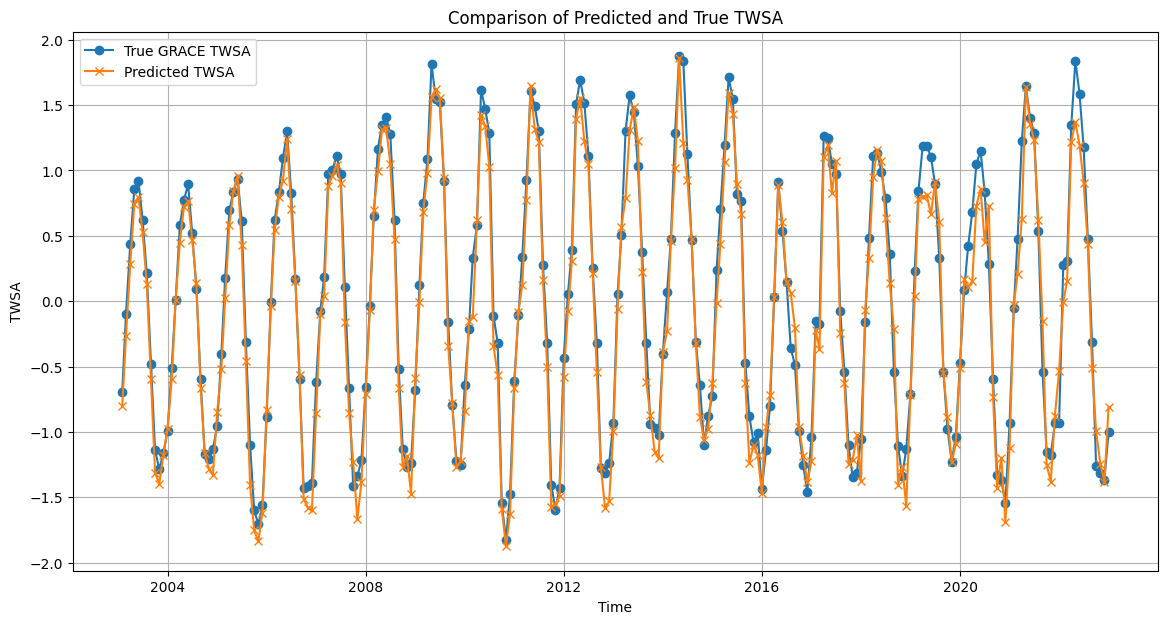

In [9]:
import matplotlib.pyplot as plt

true_tws_np = grace_tws  

# Create a time axis for plotting
dates = pd.date_range(start="2003-01-01", end="2022-12-31", freq='M')

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(dates, true_tws_np, label='True GRACE TWSA', marker='o')
plt.plot(dates, monthly_tws_predictions, label='Predicted TWSA', marker='x')
plt.title('Comparison of Predicted and True TWSA')
plt.xlabel('Time')
plt.ylabel('TWSA')
plt.legend()
plt.grid(True)
plt.show()
